In [2]:
!pip install mne
import mne
import scipy.io as sio
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut

In [3]:
import pandas as pd
import mne
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Data
df = pd.read_csv('/kaggle/input/datasets/danizo/eeg-dataset-for-adhd/adhdata.csv')

# Use your EXACT column names verified from df.columns
ch_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 
            'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']
sfreq = 128

def extract_tbr_features(df):
    features, labels, groups = [], [], []
    
    unique_ids = df['ID'].unique()
    print(f"Processing {len(unique_ids)} subjects...")
    
    for subj_id in unique_ids:
        subj_data = df[df['ID'] == subj_id]
        signals = subj_data[ch_names].values.T
        
        # MNE Object & Cleaning
        info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
        raw = mne.io.RawArray(signals, info, verbose=False)
        raw.filter(1., 40., verbose=False)
        
        # Power Spectral Density (PSD) calculation
        psds, freqs = mne.time_frequency.psd_array_welch(raw.get_data(), sfreq, fmin=1, fmax=40, verbose=False)
        
        # Theta: 4-8 Hz
        theta_idx = np.logical_and(freqs >= 4, freqs <= 8)
        theta_power = psds[:, theta_idx].mean(axis=1)
        
        # Beta: 13-30 Hz
        beta_idx = np.logical_and(freqs >= 13, freqs <= 30)
        beta_power = psds[:, beta_idx].mean(axis=1)
        
        # The core ADHD biomarker: Ratio per channel
        tbr = theta_power / beta_power
        
        features.append(tbr)
        labels.append(1 if 'ADHD' in str(subj_data['Class'].iloc[0]) else 0)
        groups.append(subj_id)
        
    return np.array(features), np.array(labels), np.array(groups)

# 2. Training with LOGO (Leave-One-Subject-Out)
X, y, groups = extract_tbr_features(df)
logo = LeaveOneGroupOut()
y_true, y_pred = [], []

print("Running Cross-Validation (this may take a minute on CPU)...")
for train_idx, test_idx in logo.split(X, y, groups):
    # n_jobs=-1 uses all CPU cores
    clf = RandomForestClassifier(n_estimators=100, max_depth=5, n_jobs=-1, random_state=42)
    clf.fit(X[train_idx], y[train_idx])
    y_true.extend(y[test_idx])
    y_pred.extend(clf.predict(X[test_idx]))

# 3. Results
print("\n--- BASELINE RESULTS ---")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.2f}")
print(classification_report(y_true, y_pred, target_names=['Control', 'ADHD']))

Processing 121 subjects...
Running Cross-Validation (this may take a minute on CPU)...

--- BASELINE RESULTS ---
Accuracy: 0.62
              precision    recall  f1-score   support

     Control       0.65      0.50      0.57        60
        ADHD       0.60      0.74      0.66        61

    accuracy                           0.62       121
   macro avg       0.63      0.62      0.61       121
weighted avg       0.63      0.62      0.61       121



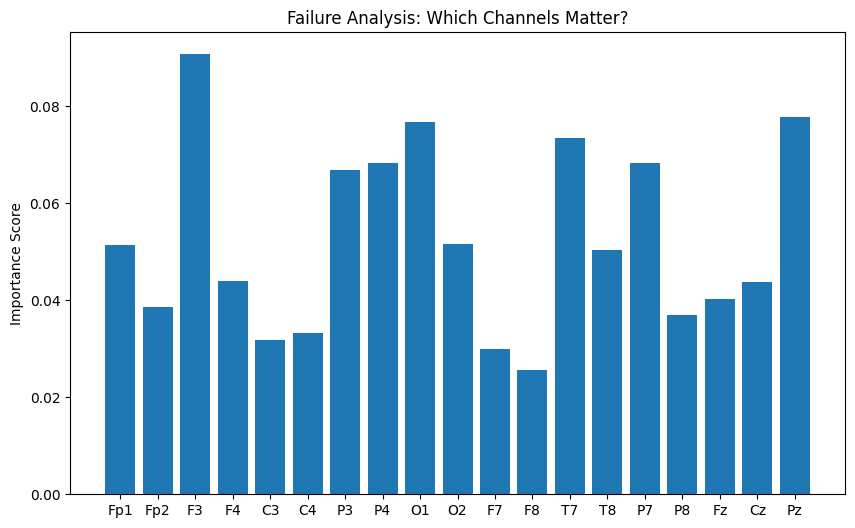

In [4]:
import matplotlib.pyplot as plt

# Get the importance of each of the 19 channels
importances = clf.feature_importances_

plt.figure(figsize=(10, 6))
plt.bar(ch_names, importances)
plt.title("Failure Analysis: Which Channels Matter?")
plt.ylabel("Importance Score")
plt.show()

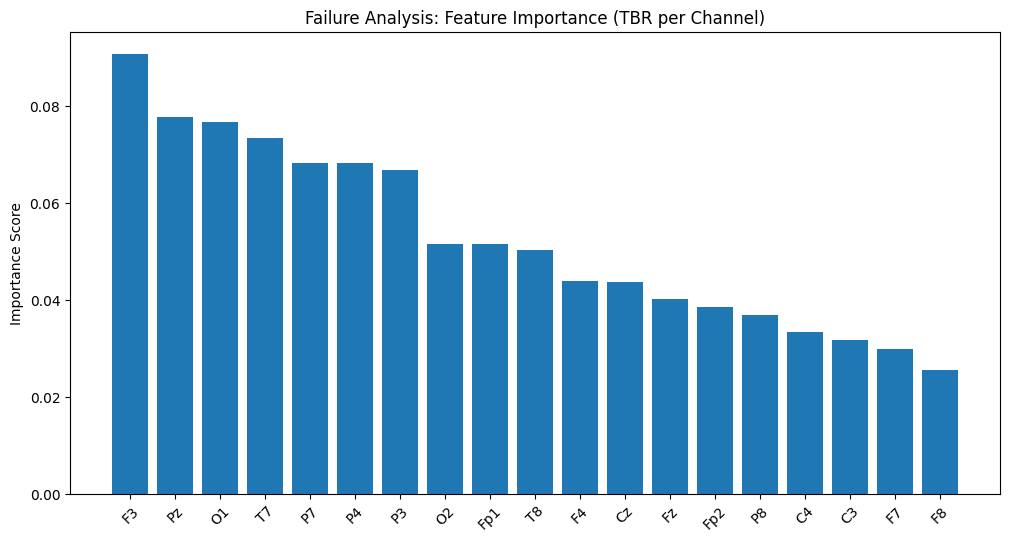

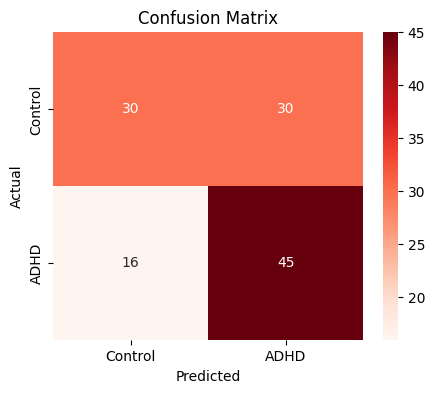

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Feature Importance - Which brain regions are being used?
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Failure Analysis: Feature Importance (TBR per Channel)")
plt.bar(range(len(ch_names)), importances[indices], align="center")
plt.xticks(range(len(ch_names)), [ch_names[i] for i in indices], rotation=45)
plt.ylabel("Importance Score")
plt.show()

# 2. Subject-Level Failure - Which specific kids are we failing?
# (Assuming you still have y_true and y_pred from the loop)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Control', 'ADHD'], yticklabels=['Control', 'ADHD'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [6]:
import numpy as np

def sliding_window_slicer(df, ch_names, sfreq=128, window_sec=4, overlap=0.5):
    win_size = int(window_sec * sfreq)
    step = int(win_size * (1 - overlap)) # 50% overlap doubles your data
    
    X, y, groups = [], [], []
    
    for subj_id in df['ID'].unique():
        subj_data = df[df['ID'] == subj_id]
        signals = subj_data[ch_names].values.T # Shape: (19 channels, time)
        label = 1 if 'ADHD' in str(subj_data['Class'].iloc[0]) else 0
        
        # Slide through the time dimension
        for start in range(0, signals.shape[1] - win_size, step):
            window = signals[:, start : start + win_size]
            X.append(window)
            y.append(label)
            groups.append(subj_id)
            
    return np.array(X), np.array(y), np.array(groups)

# Run this tonight:
X_dl, y_dl, groups_dl = sliding_window_slicer(df, ch_names)
print(f"Data Prepared: {X_dl.shape[0]} windows ready for DL.")

Data Prepared: 8278 windows ready for DL.


(8278, 19, 512)
(array([0, 1]), array([3657, 4621]))


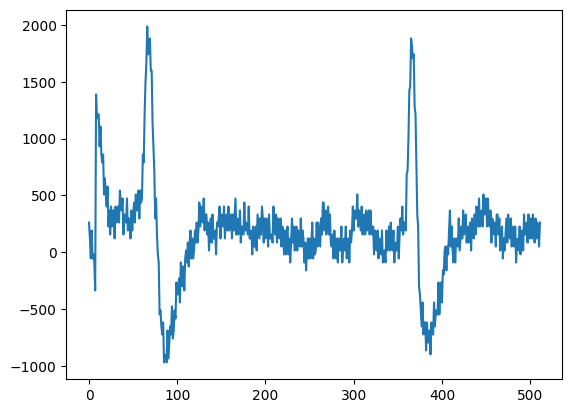

In [11]:
print(X_dl.shape)
print(np.unique(y_dl, return_counts=True))
import matplotlib.pyplot as plt; plt.plot(X_dl[0, 0, :]); plt.show()

In [12]:
import numpy as np

# Save everything into one compressed file
np.savez('adhd_windowed_data.npz', X=X_dl, y=y_dl, groups=groups_dl)

print("Data saved successfully as 'adhd_windowed_data.npz'. Ready for tomorrow!")

Data saved successfully as 'adhd_windowed_data.npz'. Ready for tomorrow!
